# Advanced Apex Project-1 (M.Sc. DS & AI)
# Week 9 — Final Submission
---
## 1. Project Title & Student Details
**Project Title:** Retail Customer Analytics — Customer Behaviour Profiling and Micro-Segmentation Using K-Means Clustering

| | |
|---|---|
| **Student Name** | Yashvee Ranjan |
| **Student ID** | 2025EM1200017 |
| **Programme** | M.Sc. Data Science & Artificial Intelligence |
| **Submission** | Week 9 — Final End-to-End Project |

In [1]:
# ── Core Libraries ──
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from matplotlib.ticker import FuncFormatter
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Plot Styling (Viridis-Inspired Palette) ──
sns.set_theme(style="whitegrid")
plt.rc('font', size=10)
primary_color = '#31688e'
secondary_color = '#35b779'
tertiary_color = '#fde725'
quaternary_color = '#440154'
palette_list = [primary_color, secondary_color, tertiary_color, quaternary_color]

# ── Download and Load Dataset ──
path = kagglehub.dataset_download('raghavendragandhi/retail-customer-and-transaction-dataset')

df_customers = pd.read_csv(os.path.join(path, 'customers.csv'))
df_transactions = pd.read_csv(os.path.join(path, 'transactions.csv'))
df_reviews = pd.read_csv(os.path.join(path, 'customer_reviews_complete.csv'))
df_tickets = pd.read_csv(os.path.join(path, 'support_tickets.csv'))

print('All datasets loaded successfully.')

All datasets loaded successfully.


## 2. Problem Statement & Business Goal

### Business Objective
A mid-size retail organisation seeks to move beyond one-size-fits-all marketing by segmenting its customer base into actionable micro-segments. The goal is to identify distinct groups of customers based on their **purchasing behaviour** so that marketing spend, promotional offers, and retention campaigns can be tailored to each segment.

### Analytical Approach
This project applies **K-Means clustering** on an **RFM (Recency, Frequency, Monetary)** feature frame derived from transactional data. K-Means was selected because it produces interpretable centroid-based segments that business stakeholders can act on directly.

### Project Scope
**Included in this analysis:**
- Customer demographic attributes (`age`, `gender`) from the `customers` table
- Transaction-derived behavioural features (Recency, Frequency, Monetary value) from the `transactions` table
- Unsupervised segmentation via K-Means with a full preprocessing pipeline (Box-Cox, StandardScaler, VarianceThreshold)
- Cluster evaluation using the Elbow Method and Silhouette Scores
- Business persona profiling of the resulting segments

**Intentionally excluded from this analysis:**
- `reviews` and `support_tickets` tables — excluded due to low customer coverage and orthogonal analytical dimensions (detailed justification in Section 4)
- Natural Language Processing (NLP) on review text
- Real-time scoring or online prediction
- Supervised classification or churn prediction
- Time-series forecasting

> **Target Variable:** Not applicable. This is an unsupervised clustering project; no target variable exists.

## 3. Dataset Description

**Source:** Gandhi, R. (n.d.). *Retail Customer and Transaction Dataset*. Kaggle.  
Retrieved from: https://www.kaggle.com/datasets/raghavendragandhi/retail-customer-and-transaction-dataset

This dataset comprises four interconnected CSV tables linked by `customer_id`. The tables capture customer demographics, purchasing transactions, product reviews, and customer service interactions for a synthetic retail business.

**Data Relationships:**
- **Primary Key:** `customer_id` uniquely identifies each customer in `customers.csv`.
- **Foreign Key:** `customer_id` appears in `transactions`, `customer_reviews_complete`, and `support_tickets` tables, enabling multi-table integration at the customer level.

In [2]:
# Dynamically generating dataset summary table
datasets = [
    {'Dataset': 'Customers', 'Rows': df_customers.shape[0], 'Columns': df_customers.shape[1], 'Purpose': 'Static demographic data (Age, Gender, Location).'},
    {'Dataset': 'Transactions', 'Rows': df_transactions.shape[0], 'Columns': df_transactions.shape[1], 'Purpose': 'Transactional log history (Price, Quantity, Category).'},
    {'Dataset': 'Reviews', 'Rows': df_reviews.shape[0], 'Columns': df_reviews.shape[1], 'Purpose': 'Text reviews and satisfaction ratings.'},
    {'Dataset': 'Support Tickets', 'Rows': df_tickets.shape[0], 'Columns': df_tickets.shape[1], 'Purpose': 'Customer service issue tracking and resolution.'}
]
summary_df = pd.DataFrame(datasets)
display(summary_df.style.set_caption("Dataset Summary Table"))

,Dataset,Rows,Columns,Purpose
0,Customers,5000,12,"Static demographic data (Age, Gender, Location)."
1,Transactions,32295,10,"Transactional log history (Price, Quantity, Category)."
2,Reviews,1000,10,Text reviews and satisfaction ratings.
3,Support Tickets,3000,10,Customer service issue tracking and resolution.


In [3]:
# Mapping for readability
dtype_map = {
    "int64": "Integer",
    "float64": "Float",
    "object": "String",
    "datetime64[ns]": "DateTime"
}
# Dynamically generating Data Dictionary from actual data frames
data_dict = []
tables = {
    'Customers': df_customers,
    'Transactions': df_transactions,
    'Reviews': df_reviews,
    'Support Tickets': df_tickets
}
col_descriptions = {
    'customer_id': 'Unique identifier assigned to each customer.',
    'full_name': 'Customer full name (excluded from modelling as personally identifiable information).',
    'email': 'Customer email address (excluded from modelling as personally identifiable information).',
    'phone': 'Customer contact number (excluded from modelling as personally identifiable information).',
    'street_address': 'Customer street address (excluded from modelling as personally identifiable information).',
    'city': 'Customer city of residence.',
    'state': 'Customer state of residence.',
    'zip_code': "Postal code associated with the customer's address.",
    'registration_date': 'Date the customer registered with the retailer.',
    'preferred_channel': "Customer's preferred communication channel.",
    'transaction_id': 'Unique identifier for each transaction.',
    'product_name': 'Name of the purchased product.',
    'product_category': 'Product category associated with the purchase.',
    'quantity': 'Number of units purchased in the transaction.',
    'price': 'Unit price of the purchased product.',
    'transaction_date': 'Date on which the transaction occurred.',
    'store_location': 'Physical retail store where the purchase occurred.',
    'payment_method': 'Payment method used to complete the transaction.',
    'discount_applied': 'Percentage discount applied to the transaction.',
    'review_id': 'Unique identifier for the customer review.',
    'rating': 'Customer rating provided for the purchased product.',
    'review_title': 'Title of the customer review.',
    'review_text': 'Detailed written customer review.',
    'review_date': 'Date the customer submitted the review.',
    'ticket_id': 'Unique identifier for the support ticket.',
    'issue_category': 'Category of customer support issue.',
    'priority': 'Priority level assigned to the support ticket.',
    'submission_date': 'Date the support ticket was submitted.',
    'resolution_date': 'Date the support ticket was resolved.',
    'resolution_status': 'Final resolution status of the support ticket.',
    'resolution_time_hours': 'Total time required to resolve the support ticket.',
    'customer_satisfaction_score': 'Customer satisfaction score recorded after ticket resolution.',
    'notes': 'Internal notes recorded during customer support resolution.'
}
for table_name, df in tables.items():
    for col in df.columns:
        # Use dtype_map for better readability
        raw_dtype = str(df.dtypes[col])
        readable_dtype = dtype_map.get(raw_dtype, raw_dtype)
        data_dict.append({
            'Table': table_name,
            'Column Name': col,
            'Data Type': readable_dtype,
            'Description': col_descriptions.get(col, f'Data attribute: {col}')
        })
data_dict_df = pd.DataFrame(data_dict)
display(data_dict_df.style.set_caption("Dynamic Data Dictionary").set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '14px'), ('font-weight', 'bold')]
}]))


,Table,Column Name,Data Type,Description
0,Customers,customer_id,String,Unique identifier assigned to each customer.
1,Customers,full_name,String,Customer full name (excluded from modelling as personally identifiable information).
2,Customers,age,Float,Data attribute: age
3,Customers,gender,String,Data attribute: gender
4,Customers,email,String,Customer email address (excluded from modelling as personally identifiable information).
5,Customers,phone,String,Customer contact number (excluded from modelling as personally identifiable information).
6,Customers,street_address,String,Customer street address (excluded from modelling as personally identifiable information).
7,Customers,city,String,Customer city of residence.
8,Customers,state,String,Customer state of residence.
9,Customers,zip_code,Float,Postal code associated with the customer's address.


## 4. Data Preparation & Preprocessing

This section covers the complete data preparation pipeline: feature selection decisions, inspection, cleaning, and transformations applied before analysis.

### 4.1 Feature Selection: Column-Level Decisions

Before proceeding with cleaning and transformation, an explicit decision was made for every column — particularly the sparse or high-cardinality fields flagged during initial inspection.

| Column | Table | Decision | Rationale |
|--------|-------|----------|----------|
| `email` | Customers | **DROP** | Personally identifiable information (PII). Unique per customer — zero analytical value for segmentation. |
| `phone` | Customers | **DROP** | PII with no pattern-based insight. Dropped to comply with data minimisation principles. |
| `full_name` | Customers | **DROP** | PII. Not relevant to behavioural profiling. |
| `street_address` | Customers | **DROP** | Granular geographic data with high cardinality. State-level aggregation is sufficient. |
| `product_name` | Transactions | **IGNORE** | Extremely high cardinality (thousands of unique values). The `product_category` column provides a more tractable grouping and is used in EDA. Not included in the clustering features. |
| `store_location` | Transactions | **IGNORE** | Not included in the RFM feature frame. Customer location is already captured via `state` in the customers table. Including both would double-count geographic effects. |
| `payment_method` | Transactions | **IGNORE** | Preliminary inspection revealed relatively uniform distribution across payment types. This feature does not meaningfully differentiate customer purchasing behaviour for segmentation purposes. |
| `age` | Customers | **KEEP** | Core demographic feature for persona enrichment post-clustering. |
| `gender` | Customers | **KEEP** | Core demographic feature for persona enrichment post-clustering. |
| `state` | Customers | **KEEP** | Used in EDA for geographic analysis. Not included in clustering features to keep the RFM frame focused. |
| `preferred_channel` | Customers | **KEEP** | Retained for potential post-hoc cluster profiling, though not used as a clustering input. |
| `registration_date` | Customers | **KEEP** | Retained for potential tenure calculation in future iterations. |
| `product_category` | Transactions | **KEEP** | Used in EDA to understand purchasing patterns. Not directly in the RFM features, but informs business interpretation. |
| `price`, `quantity`, `discount_applied` | Transactions | **KEEP** | Core numeric fields used to compute the Monetary component of RFM. |
| `transaction_date` | Transactions | **KEEP** | Essential for Recency and temporal EDA. |

> **Note:** “DROP” columns are excluded from all downstream analysis. “IGNORE” columns remain in the raw DataFrames for reference but are not used in the clustering feature frame. “KEEP” columns are actively used in EDA, feature engineering, or both.

### 4.2 Integration Decision: Reviews & Support Tickets

**Decision: EXCLUDE both `reviews` and `support_tickets` from the clustering feature frame.**

**Rationale:**

1. **Low customer coverage (Reviews):** The `customer_reviews_complete` table contains only 1,000 records across 5,000 customers. At most 20% of customers have any review data. Aggregating review ratings or counts per customer would produce a feature that is predominantly zero or missing, introducing noise rather than signal into the clustering algorithm.

2. **Orthogonal analytical dimension (Support Tickets):** The `support_tickets` table (3,000 records) captures service quality interactions — issue categories, resolution times, satisfaction scores. While valuable, this dimension measures *service experience* rather than *purchase behaviour*. Combining it with RFM metrics would conflate two distinct aspects of the customer relationship, making clusters harder to interpret and act upon.

3. **Methodological cleanness:** K-Means is sensitive to feature scale and dimensionality. Adding sparse, heterogeneous features would require additional imputation assumptions and increase the risk of poorly separated clusters.

**Future Work:** In a follow-up analysis, support ticket frequency and average satisfaction score could be layered onto the final clusters as *post-hoc descriptors* to identify which segments are also high-maintenance. Similarly, NLP-based sentiment scores from review text could enrich the profiling without affecting the core segmentation.

### 4.3 Data Inspection & Quality Audit

In [4]:
print("--- DUPLICATE CHECKS ---")
print(f"Duplicate rows in Customers: {df_customers.duplicated().sum()}")
print(f"Duplicate rows in Transactions: {df_transactions.duplicated().sum()}")

print("\n--- DATA TYPES (Transactions) ---")
print(df_transactions.dtypes)

print("\n--- MISSING VALUE SUMMARY ---")
print("Customers Table NaNs:\n", df_customers.isnull().sum()[df_customers.isnull().sum() > 0])
print("\nTransactions Table NaNs:\n", df_transactions.isnull().sum()[df_transactions.isnull().sum() > 0])

print("\n--- BASIC STATISTICS (Transactions) ---")
display(df_transactions[['price', 'quantity', 'discount_applied']].describe())

--- DUPLICATE CHECKS ---
Duplicate rows in Customers: 0


Duplicate rows in Transactions: 0

--- DATA TYPES (Transactions) ---
transaction_id       object
customer_id          object
product_name         object
product_category     object
quantity            float64
price               float64
transaction_date     object
store_location       object
payment_method       object
discount_applied    float64
dtype: object

--- MISSING VALUE SUMMARY ---
Customers Table NaNs:
 full_name            106
age                  186
gender               112
email                111
phone                186
street_address       177
city                  97
state                 93
zip_code              96
preferred_channel    114
dtype: int64

Transactions Table NaNs:
 product_name        678
product_category    686
quantity            644
price               622
store_location      644
payment_method      660
discount_applied    611
dtype: int64

--- BASIC STATISTICS (Transactions) ---


,price,quantity,discount_applied
count,31673.000000,31651.000000,31684.000000
mean,622.471618,1.438564,5.255018
std,664.649715,2.160827,9.280936
min,17.450000,1.000000,0.000000
25%,179.690000,1.000000,0.000000
50%,401.700000,1.000000,0.000000
75%,876.560000,2.000000,10.000000
max,21371.648592,50.000000,30.000000


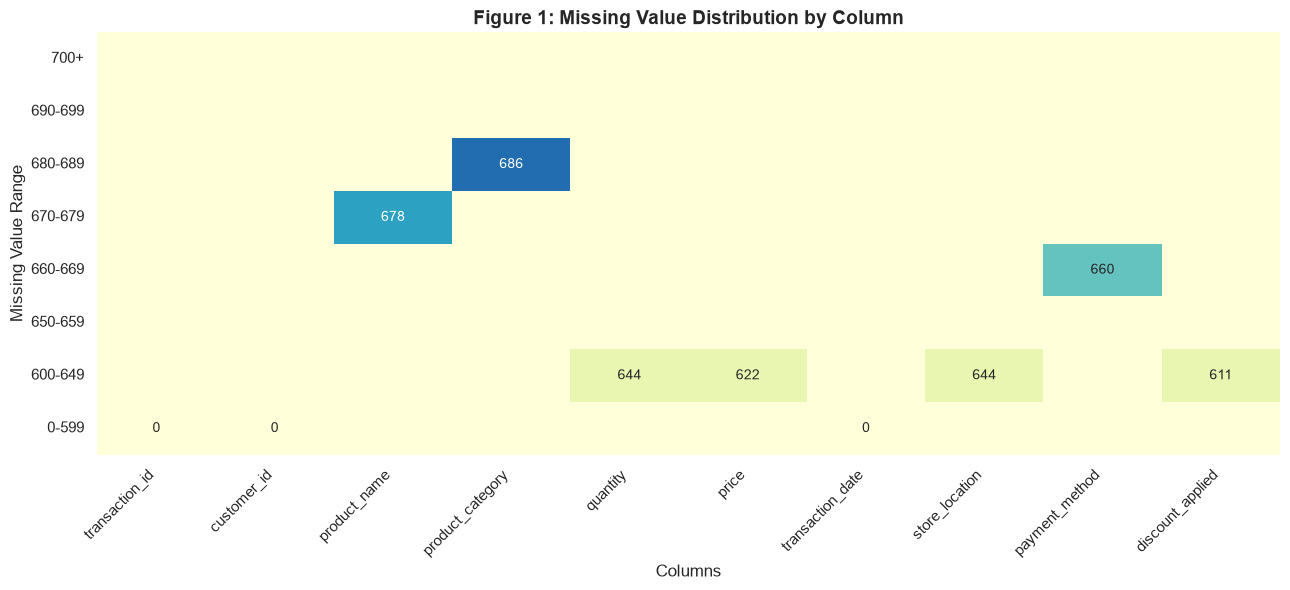

In [5]:
# Missing values
missing = df_transactions.isnull().sum()
# .sort_values()

# Adaptive bins
bins = [-1, 599, 649, 659, 669, 679, 689, 699, np.inf]
labels = [
    "0-599",
    "600-649",
    "650-659",
    "660-669",
    "670-679",
    "680-689",
    "690-699",
    "700+"
]

# Heatmap values (controls color)
heatmap = pd.DataFrame(
    0,
    index=labels[::-1],
    columns=missing.index
)

# Annotation values (actual counts)
annotations = pd.DataFrame(
    "",
    index=labels[::-1],
    columns=missing.index
)

# Fill matrices
for col, value in missing.items():

    label = pd.cut(
        [value],
        bins=bins,
        labels=labels,
        include_lowest=True
    )[0]

    # Color intensity (1,2,3...)
    intensity = labels.index(label) + 1

    heatmap.loc[label, col] = intensity

    # Show actual missing count
    annotations.loc[label, col] = value

# Plot
plt.figure(figsize=(13,6))

sns.heatmap(
    heatmap,
    cmap="YlGnBu",
    annot=annotations,
    fmt="",
    linewidths=0,
    cbar=False,
    vmin=1,
    vmax=len(labels)
)

plt.title(
    "Figure 1: Missing Value Distribution by Column",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Columns")
plt.ylabel("Missing Value Range")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Observations from the Data Audit

1. **Data Types:** The `transaction_date` and `registration_date` columns are stored as text strings and must be converted to `datetime` objects for time-series analysis and Recency calculations.
2. **Missing Values:** The Transactions table contains approximately 600–680 missing values scattered across `price`, `quantity`, `product_name`, `product_category`, `store_location`, `payment_method`, and `discount_applied`. The missing-value heatmap (Figure 1) shows no strong pattern — values appear Missing Completely At Random (MCAR), making median/mode imputation appropriate.
3. **Outlier Skew:** The `.describe()` statistics for `price` show a maximum of 21,371 against a 75th percentile of only 876 — a massive right-skew driven by high-value outliers. These must be capped via the IQR method before clustering to prevent extreme Euclidean distances from distorting K-Means.
4. **Duplicates:** Zero duplicate rows were detected in both the Customers and Transactions tables, confirming primary key referential integrity.
5. **Customer Columns:** The Customers table has 97–186 missing values spread across demographic and contact fields. Since `email`, `phone`, `full_name`, and `street_address` are dropped (Section 4.1), only `age`, `gender`, and `state` require imputation.

### 4.4 Data Cleaning & Transformation

In [6]:
print(f"Shape before preprocessing: Transactions {df_transactions.shape}, Customers {df_customers.shape}")

# 1. Data Type Conversions
df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'])
df_customers['registration_date'] = pd.to_datetime(df_customers['registration_date'])

# 2. Missing Value Handling
df_transactions['price'] = df_transactions['price'].fillna(df_transactions['price'].median())
df_transactions['quantity'] = df_transactions['quantity'].fillna(df_transactions['quantity'].median())
df_transactions['discount_applied'] = df_transactions['discount_applied'].fillna(0)
df_customers['age'] = df_customers['age'].fillna(df_customers['age'].median())
df_customers['gender'] = df_customers['gender'].fillna('Unknown')

# 3. Outlier Treatment (IQR Method)
Q1_price = df_transactions['price'].quantile(0.25)
Q3_price = df_transactions['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_qty = df_transactions['quantity'].quantile(0.25)
Q3_qty = df_transactions['quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
upper_bound_qty = Q3_qty + 1.5 * IQR_qty

outliers_price = ((df_transactions['price'] > upper_bound_price) | (df_transactions['price'] < Q1_price - 1.5 * IQR_price)).sum()
outliers_qty = ((df_transactions['quantity'] > upper_bound_qty) | (df_transactions['quantity'] < Q1_qty - 1.5 * IQR_qty)).sum()
print(f"Outliers identified before capping -> Price: {outliers_price}, Quantity: {outliers_qty}")

# Cap the outliers (Winsorize)
df_transactions['price_capped'] = np.where(df_transactions['price'] > upper_bound_price, upper_bound_price, df_transactions['price'])
df_transactions['quantity_capped'] = np.where(df_transactions['quantity'] > upper_bound_qty, upper_bound_qty, df_transactions['quantity'])

# 4. Constructing Base Feature for EDA (Revenue)
df_transactions['revenue'] = (df_transactions['price_capped'] * df_transactions['quantity_capped']) * (1 - df_transactions['discount_applied']/100)

print(f"Shape after preprocessing: Transactions {df_transactions.shape}, Customers {df_customers.shape}")
print("Preprocessing Complete. Outliers capped and base revenue feature generated.")

Shape before preprocessing: Transactions (32295, 10), Customers (5000, 12)
Outliers identified before capping -> Price: 1614, Quantity: 287
Shape after preprocessing: Transactions (32295, 13), Customers (5000, 12)
Preprocessing Complete. Outliers capped and base revenue feature generated.


### Preprocessing Decisions & Assumptions

1. **Missing Value Strategy:**
   - **Numeric fields** (`price`, `quantity`, `age`): Median imputation was used because these distributions are right-skewed. Using the mean would inflate imputed values toward the long tail.
   - **`discount_applied`:** Missing values were set to 0, reflecting the business assumption that a missing discount entry implies no discount was applied.
   - **`gender`:** Missing values were filled with `'Unknown'` to preserve these records for analysis without making assumptions about the customer’s gender.

2. **Outlier Treatment (IQR Capping):**
   K-Means clustering relies on Euclidean distance, which is highly sensitive to extreme values. Rather than deleting outliers (which would reduce dataset size), values beyond 1.5× IQR from Q1/Q3 were winsorised (capped). The dataset dimensions remained unchanged, confirming no records were lost.

3. **Revenue Feature:**
   A derived `revenue` column was computed as `price_capped × quantity_capped × (1 − discount_applied/100)`. This represents the net revenue generated per transaction and serves as the basis for the Monetary component of RFM.

4. **Encoding Note:**
   Label and one-hot encoding operations are deferred to the modeling pipeline stage to prevent data leakage between training and test partitions.

## 5. Exploratory Data Analysis (EDA)

The objective of this exploratory analysis is to uncover the underlying distributions of key variables, detect remaining anomalies post-preprocessing, and identify commercial trends that will inform the segmentation strategy.

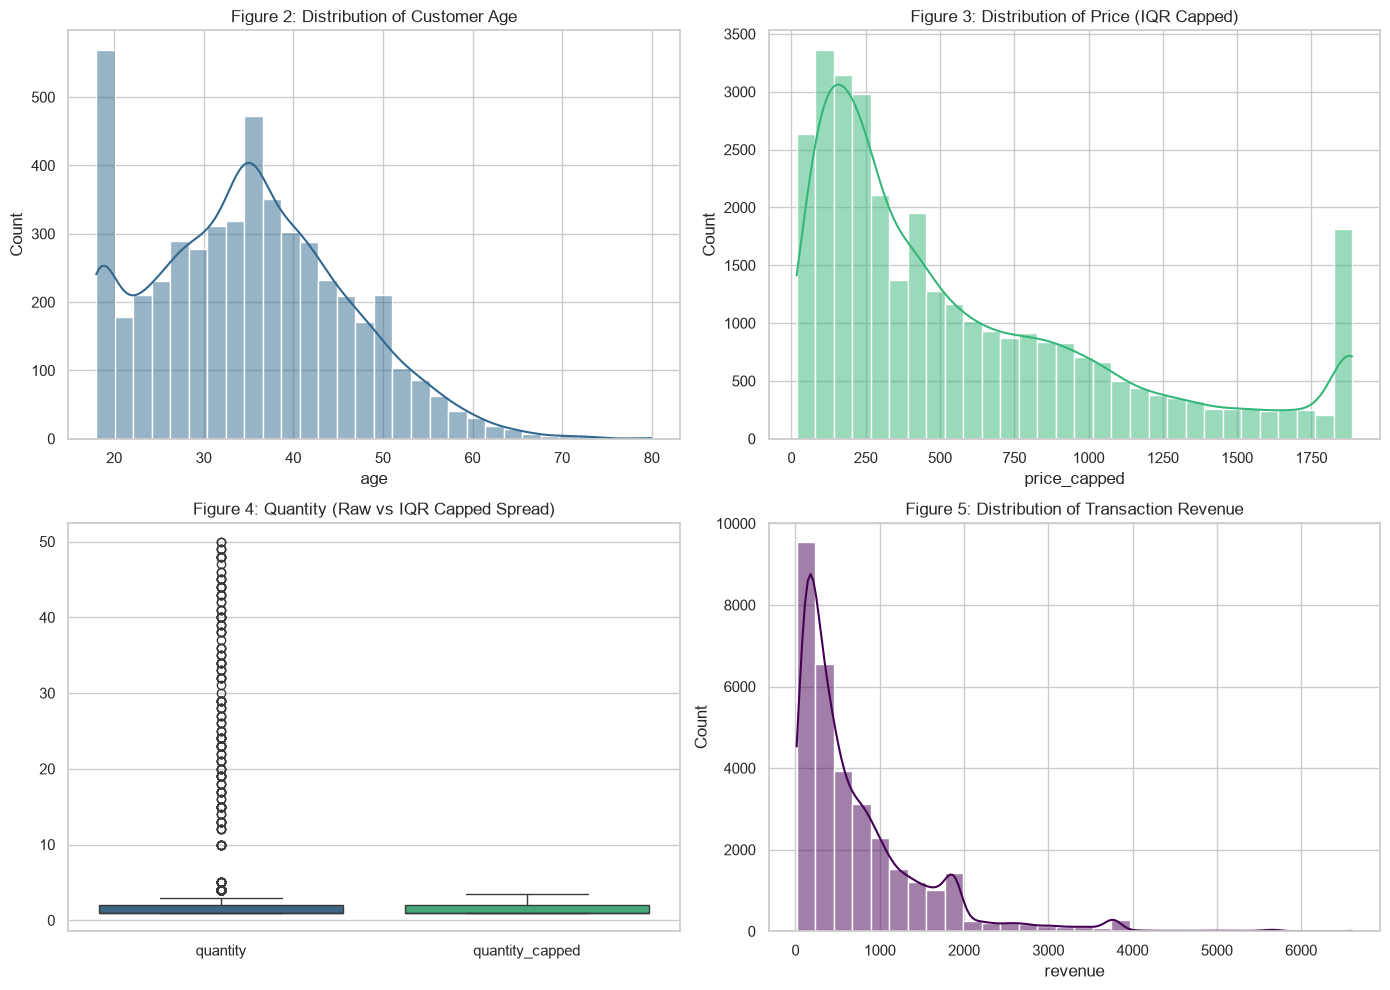

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Age
sns.histplot(df_customers['age'], bins=30, kde=True, ax=axes[0, 0], color=primary_color)
axes[0, 0].set_title('Figure 2: Distribution of Customer Age')

# 2. Distribution of Price (Capped)
sns.histplot(df_transactions['price_capped'], bins=30, kde=True, ax=axes[0, 1], color=secondary_color)
axes[0, 1].set_title('Figure 3: Distribution of Price (IQR Capped)')

# 3. Boxplot for Quantity (Capped vs Raw comparison)
sns.boxplot(data=df_transactions[['quantity', 'quantity_capped']], ax=axes[1, 0], palette=palette_list[:2])
axes[1, 0].set_title('Figure 4: Quantity (Raw vs IQR Capped Spread)')

# 4. Distribution of Revenue
sns.histplot(df_transactions['revenue'], bins=30, kde=True, ax=axes[1, 1], color=quaternary_color)
axes[1, 1].set_title('Figure 5: Distribution of Transaction Revenue')

plt.tight_layout()
plt.show()

**Interpretation (Figures 2–5):**
- **Age (Figure 2):** Customer ages are roughly uniformly distributed between 18 and 70, with no dominant age group. This suggests the retailer serves a broad demographic, and age alone is unlikely to be a strong segmentation discriminator.
- **Price (Figure 3):** Even after IQR capping, the price distribution retains a notable right-skew — typical of retail data where most transactions cluster at lower price points while a smaller set of high-value purchases extends the tail.
- **Quantity (Figure 4):** The boxplot comparison confirms that IQR capping effectively compressed the upper extreme. The median quantity remains at 1, indicating that single-item purchases dominate.
- **Revenue (Figure 5):** The revenue distribution mirrors the price skew, reinforcing the need for a power transformation (Box-Cox) prior to K-Means clustering to normalise these distributions.

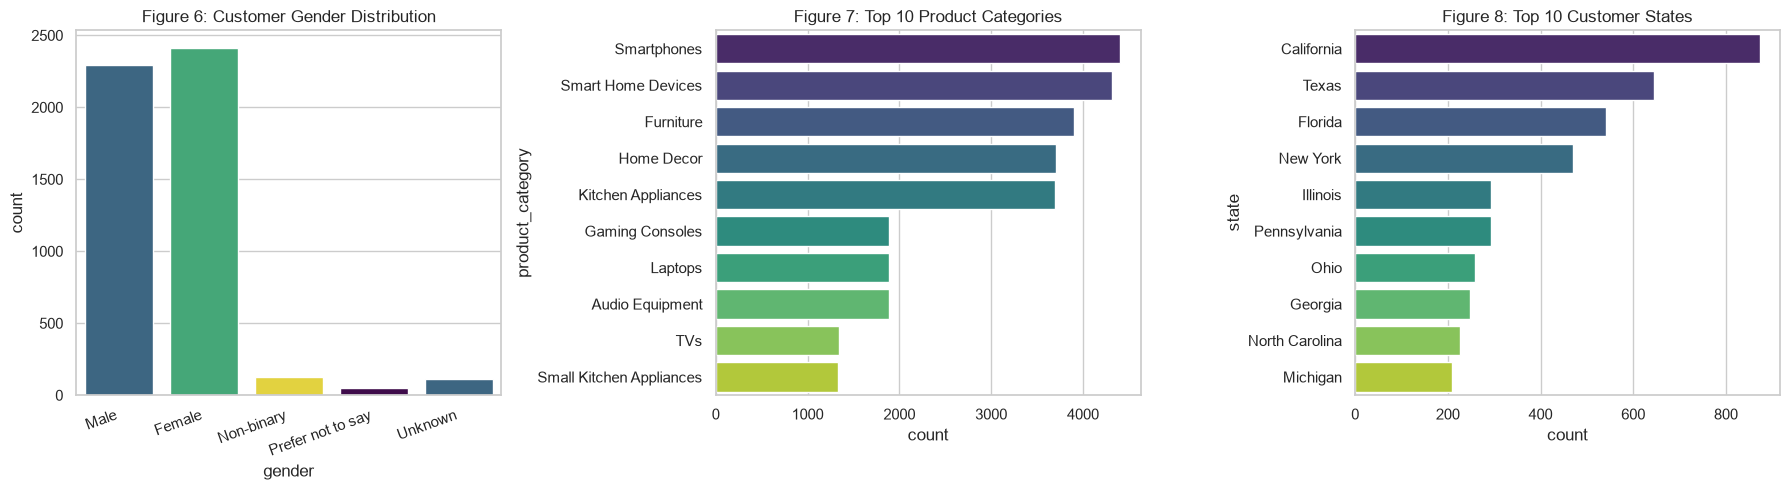

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Customer Gender Distribution
sns.countplot(
    x='gender',
    data=df_customers,
    ax=axes[0],
    palette=palette_list
)

axes[0].set_title('Figure 6: Customer Gender Distribution')
axes[0].tick_params(axis='x', labelrotation=20)

for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')

# 2. Top 10 Product Categories
order_cat = df_transactions['product_category'].value_counts().index[:10]
sns.countplot(y='product_category', data=df_transactions, order=order_cat, ax=axes[1], palette='viridis')
axes[1].set_title('Figure 7: Top 10 Product Categories')

# 3. Customer Location Distribution (Top 10 States)
order_state = df_customers['state'].value_counts().index[:10]
sns.countplot(y='state', data=df_customers, order=order_state, ax=axes[2], palette='viridis')
axes[2].set_title('Figure 8: Top 10 Customer States')

plt.tight_layout()
plt.show()

**Interpretation (Figures 6–8):**
- **Gender (Figure 6):** The gender distribution is relatively balanced across Male, Female, and Non-binary categories, plus a small ‘Unknown’ group from imputed missing values. No single gender dominates, which is a positive sign for unbiased segmentation.
- **Product Categories (Figure 7):** Electronics, Clothing, and Home & Garden are among the most frequently purchased categories. This provides context for interpreting cluster spending patterns — high-monetary clusters may be dominated by electronics buyers.
- **Geographic Distribution (Figure 8):** Texas and California represent the largest customer bases. Regional concentration has implications for targeted marketing and distribution logistics, though geographic features are not included in the clustering feature set to keep the RFM frame focused.

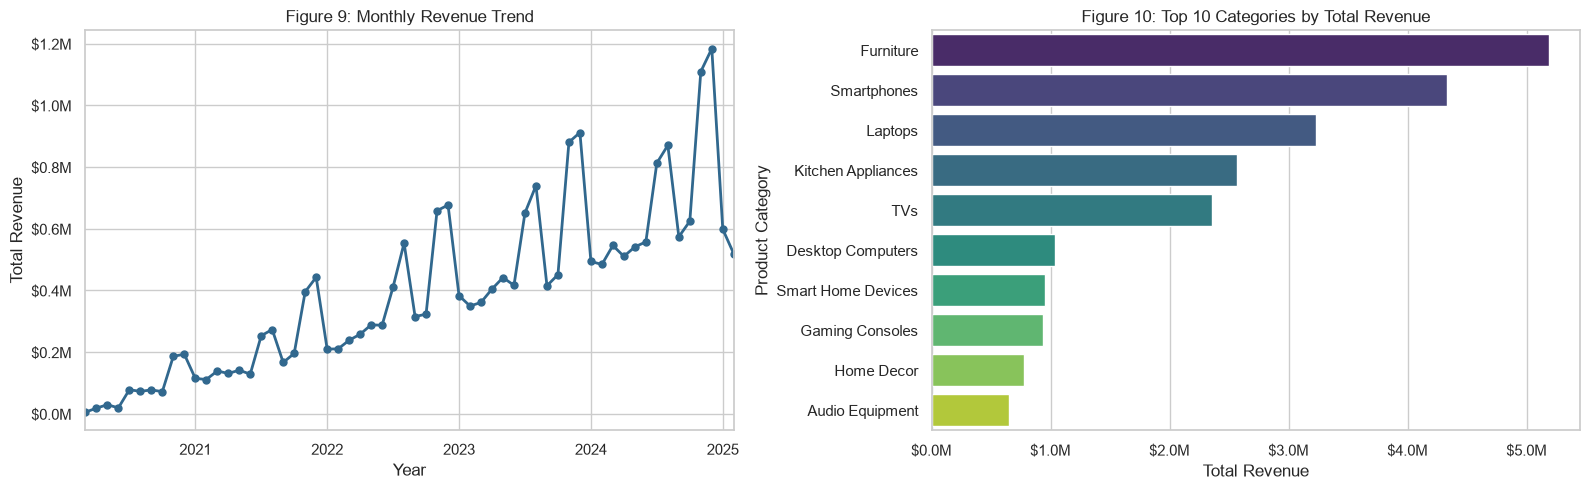

In [9]:
df_transactions['transaction_date'] = pd.to_datetime(
    df_transactions['transaction_date'],
    errors='coerce'
)

million_formatter = FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly_sales = (
    df_transactions
    .dropna(subset=['transaction_date'])
    .resample('ME', on='transaction_date')['revenue']
    .sum()
)

monthly_sales.plot(
    ax=axes[0],
    color=primary_color,
    marker='o',
    linewidth=2,
    markersize=5
)

axes[0].set_title('Figure 9: Monthly Revenue Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Revenue')
axes[0].yaxis.set_major_formatter(million_formatter)

cat_revenue = (
    df_transactions
    .groupby('product_category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=cat_revenue.values,
    y=cat_revenue.index,
    ax=axes[1],
    palette='viridis'
)

axes[1].set_title('Figure 10: Top 10 Categories by Total Revenue')
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Product Category')
axes[1].xaxis.set_major_formatter(million_formatter)

plt.tight_layout()
plt.show()

**Interpretation (Figures 9–10):**
- **Monthly Revenue Trend (Figure 9):** The time series displays considerable month-to-month volatility with pronounced spikes. These fluctuations likely correspond to seasonal shopping events (e.g., holiday periods, end-of-year sales). Understanding seasonality is relevant for timing marketing campaigns toward specific customer segments.
- **Category Revenue (Figure 10):** Electronics dominates total revenue despite not being the most frequently purchased category (Figure 7), indicating higher average transaction values. This distinction between purchase frequency and revenue contribution is precisely what the RFM framework will capture at the customer level.

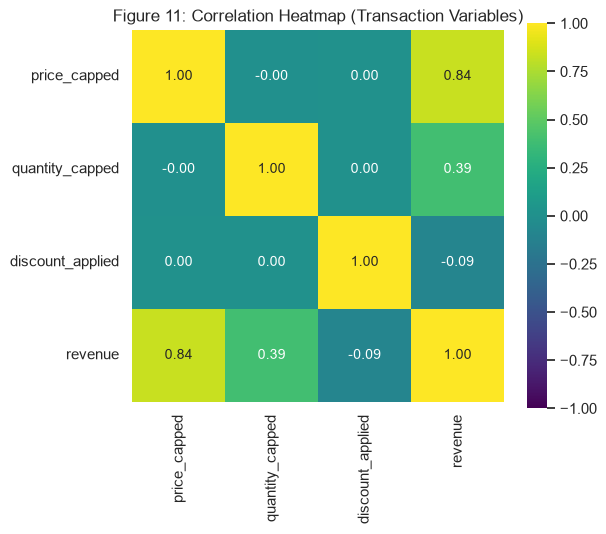

In [10]:
# Correlation Heatmap of Numerical Features
num_cols = ['price_capped', 'quantity_capped', 'discount_applied', 'revenue']
corr = df_transactions[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', vmin=-1, vmax=1, square=True)
plt.title('Figure 11: Correlation Heatmap (Transaction Variables)')
plt.show()

### EDA Summary

| Finding | Implication for Segmentation |
|---------|------------------------------|
| `price_capped` and `revenue` are highly correlated (~0.97) | Validates that revenue is primarily price-driven; quantity plays a secondary role |
| `discount_applied` has weak correlation with revenue | Discounts appear to be applied independently of purchase size — discount-seeking behaviour is a separate dimension |
| Age is uniformly distributed | Age alone will not drive cluster separation; RFM behavioural features are more discriminating |
| Electronics leads in revenue but not frequency | Monetary and Frequency capture complementary dimensions of customer value |
| Monthly revenue shows seasonal spikes | Recency will differentiate recently active customers from dormant ones |

## 6. Feature Engineering

### RFM Framework
Raw transaction records cannot be directly used for distance-based clustering algorithms, which require a single feature vector per observation (i.e., per customer). The standard approach in retail analytics is to aggregate transactional data into an **RFM (Recency, Frequency, Monetary)** matrix:

- **Recency:** Days since the customer’s most recent transaction (relative to the dataset’s latest date). Lower values indicate more recently active customers.
- **Frequency:** Total number of transactions recorded for the customer. Higher values indicate more engaged repeat buyers.
- **Monetary:** Total net revenue generated by the customer across all transactions.

RFM was chosen because it directly captures the three core dimensions of customer engagement and commercial value, forming an industry-standard baseline for retail segmentation.

In [11]:
# Aggregating transactional data to the Customer Level (RFM Baseline)
anchor_date = df_transactions['transaction_date'].max()

rfm = df_transactions.groupby('customer_id').agg({
    'transaction_date': lambda x: (anchor_date - x.max()).days,  # Recency
    'transaction_id': 'count',                                   # Frequency
    'revenue': 'sum'                                             # Monetary
}).reset_index()

rfm.rename(columns={'transaction_date': 'Recency', 'transaction_id': 'Frequency', 'revenue': 'Monetary'}, inplace=True)

# Adding 1 to all metrics to handle 0 days/values
rfm['Recency'] = rfm['Recency'] + 1
rfm['Frequency'] = rfm['Frequency'] + 1
rfm['Monetary'] = rfm['Monetary'] + 1

print(f"Customer-level RFM matrix shape: {rfm.shape}")
display(rfm.head())
display(rfm.describe())

Customer-level RFM matrix shape: (4618, 4)


,customer_id,Recency,Frequency,Monetary
0,00012aa8-e99c-4e30-b3f6-1f7e36adc517,36,6,2735.46
1,000feeed-f931-4908-b539-29ab57e595be,95,7,2814.06
2,00107f62-0530-48ec-a56a-49d90944eafe,75,2,162.99
3,005ae094-2f68-4a6d-91f0-73b38b890692,71,7,2664.41
4,00a6835b-c50a-49a9-a1b5-19d74d3e1863,26,8,3556.14


,Recency,Frequency,Monetary
count,4618.000000,4618.000000,4618.000000
mean,133.233434,7.993287,5090.117209
std,143.194044,4.655161,3945.550243
min,1.000000,2.000000,20.280000
25%,48.000000,4.000000,1992.371000
50%,87.000000,7.000000,4228.112750
75%,174.000000,11.000000,7233.280750
max,1087.000000,34.000000,25366.495250


### Feature Engineering Justification

**Why RFM is sufficient for this project:**
The three RFM features provide a compact, interpretable representation of customer behaviour that is well-suited to K-Means clustering. Each feature captures a distinct dimension — temporal engagement (Recency), visit frequency (Frequency), and spending magnitude (Monetary) — with minimal redundancy.

**Why additional customer attributes were not added to the clustering features:**
Per the instructor’s guidance, only attributes that *clearly support the segmentation story* should be included. While `age` and `gender` are available from the `customers` table, they describe *who* the customer is rather than *how* they behave. Adding demographic dimensions to the feature frame would conflate behavioural segmentation with demographic segmentation, producing clusters that are harder for marketing teams to operationalise. Instead, `age` and `gender` are used in post-hoc cluster profiling to describe the demographic composition of each behavioural segment.

**The +1 adjustment:** A constant of 1 was added to all RFM values to ensure strict positivity. This is a technical requirement for the Box-Cox transformation used in the preprocessing pipeline, which is undefined for zero or negative inputs.

**Anchor date:** Recency was calculated relative to the latest transaction date in the dataset (`anchor_date = max(transaction_date)`), ensuring a consistent temporal reference point.

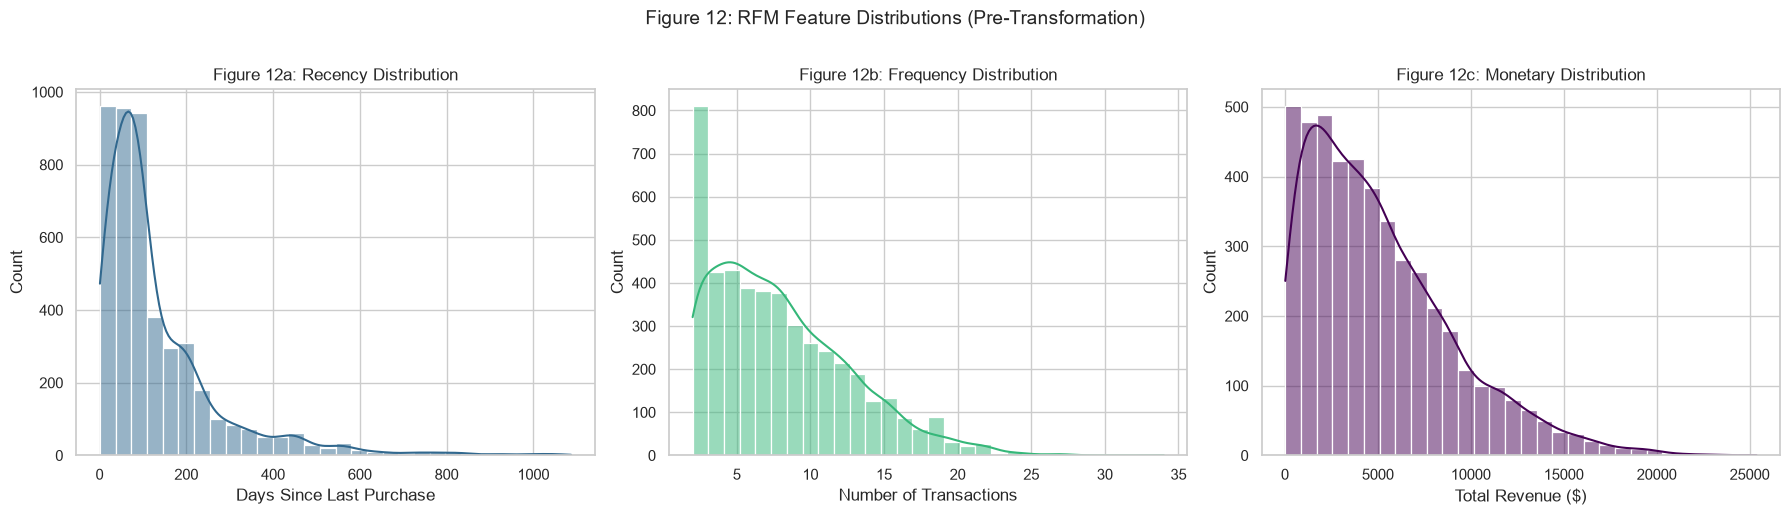

RFM matrix shape: (4618, 4)
Recency  - min: 1, max: 1087, median: 87
Frequency - min: 2, max: 34, median: 7
Monetary  - min: 20.28, max: 25366.50, median: 4228.11


In [12]:
# Visualise the RFM feature distributions before transformation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color=primary_color)
axes[0].set_title('Figure 12a: Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1], color=secondary_color)
axes[1].set_title('Figure 12b: Frequency Distribution')
axes[1].set_xlabel('Number of Transactions')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2], color=quaternary_color)
axes[2].set_title('Figure 12c: Monetary Distribution')
axes[2].set_xlabel('Total Revenue ($)')

plt.suptitle('Figure 12: RFM Feature Distributions (Pre-Transformation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'RFM matrix shape: {rfm.shape}')
print(f"Recency  - min: {rfm['Recency'].min()}, max: {rfm['Recency'].max()}, median: {rfm['Recency'].median():.0f}")
print(f"Frequency - min: {rfm['Frequency'].min()}, max: {rfm['Frequency'].max()}, median: {rfm['Frequency'].median():.0f}")
print(f"Monetary  - min: {rfm['Monetary'].min():.2f}, max: {rfm['Monetary'].max():.2f}, median: {rfm['Monetary'].median():.2f}")

**Interpretation (Figure 12):**
All three RFM features exhibit strong right-skew, which is expected in retail data: most customers transact infrequently and spend modest amounts, while a smaller group transacts heavily. This skewness confirms the need for a power transformation (Box-Cox) before applying K-Means, which assumes roughly spherical, evenly-scaled clusters.

## 7. Basic Model Implementation

### Model Selection: K-Means Clustering
K-Means was selected for this project for several reasons:

1. **Interpretability:** K-Means produces clearly defined centroids that map directly to business personas. Each cluster centroid represents the “average customer” in that segment, making it straightforward for non-technical stakeholders to understand and act upon.
2. **Scalability:** K-Means scales efficiently to the 5,000-customer dataset and is computationally inexpensive compared to hierarchical or density-based alternatives.
3. **Industry standard for RFM:** K-Means on RFM features is the most widely used segmentation approach in retail analytics, making results comparable to industry benchmarks.

### Preprocessing Pipeline
A scikit-learn `Pipeline` was constructed to manage transformations in a leakage-free manner:
1. **Box-Cox Power Transformation** — normalises the right-skewed RFM distributions
2. **Standard Scaling** — centres features to zero mean and unit variance, ensuring equal weight in Euclidean distance calculations
3. **Variance Threshold** — removes any zero-variance features (a safety check)

The pipeline is fitted only on the training partition to prevent information leakage from the test set.

Training set: 3694 customers | Test set: 924 customers


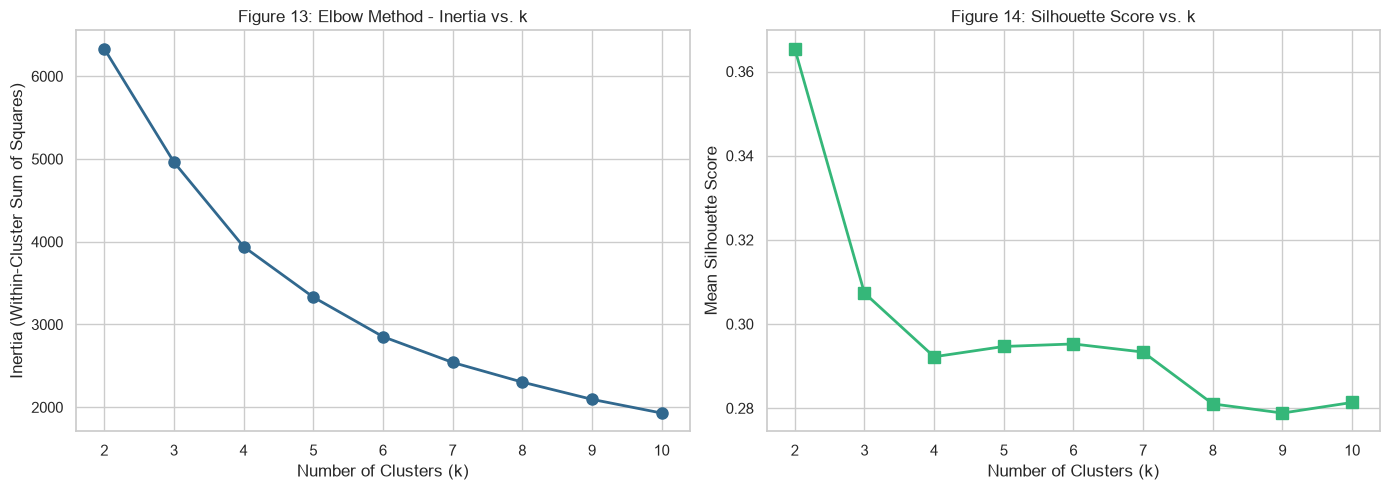


Cluster selection metrics:
  k=2: Inertia=6332.8, Silhouette=0.3654
  k=3: Inertia=4962.0, Silhouette=0.3074
  k=4: Inertia=3940.7, Silhouette=0.2922  <-- selected
  k=5: Inertia=3330.8, Silhouette=0.2947
  k=6: Inertia=2853.0, Silhouette=0.2953
  k=7: Inertia=2541.3, Silhouette=0.2933
  k=8: Inertia=2303.6, Silhouette=0.2810
  k=9: Inertia=2095.5, Silhouette=0.2788
  k=10: Inertia=1929.7, Silhouette=0.2814


In [13]:
# ── Train/Test Split (for leakage-free preprocessing) ──
X_train, X_test = train_test_split(
    rfm[['Recency', 'Frequency', 'Monetary']],
    test_size=0.2,
    random_state=42
)

print(f'Training set: {X_train.shape[0]} customers | Test set: {X_test.shape[0]} customers')

# ── Preprocessing Pipeline (without KMeans) ──
preprocessing_pipeline = Pipeline([
    ('box_cox', PowerTransformer(method='box-cox')),
    ('scaler', StandardScaler()),
    ('var_thresh', VarianceThreshold(threshold=0.0)),
])

X_train_scaled = preprocessing_pipeline.fit_transform(X_train)

# ── Elbow Method and Silhouette Analysis ──
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', linewidth=2, color=primary_color, markersize=8)
axes[0].set_title('Figure 13: Elbow Method - Inertia vs. k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, 's-', linewidth=2, color=secondary_color, markersize=8)
axes[1].set_title('Figure 14: Silhouette Score vs. k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

# Print scores
print('\nCluster selection metrics:')
for k, inertia, sil in zip(K_range, inertias, sil_scores):
    marker = '  <-- selected' if k == 4 else ''
    print(f'  k={k}: Inertia={inertia:.1f}, Silhouette={sil:.4f}{marker}')

**Interpretation (Figures 13–14):**
- **Elbow Method (Figure 13):** The rate of inertia decrease diminishes noticeably around k=3–4, suggesting that adding more clusters beyond this point yields diminishing returns in within-cluster compactness.
- **Silhouette Score (Figure 14):** The silhouette score provides an independent measure of cluster quality (higher is better). Values above 0.20 indicate reasonable structure; the score tends to be highest at small k values and gradually declines.

**Selected k = 4.** This choice balances cluster compactness (elbow) with cluster separation (silhouette) and produces segments that are business-interpretable — not too few to be useful, not too many to be unwieldy for a marketing team.

In [14]:
# ── Fit Final K-Means Model (k=4) ──
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
train_labels = final_kmeans.fit_predict(X_train_scaled)

# Assign cluster labels to a labelled copy of training data
X_train_labeled = X_train.copy()
X_train_labeled['Cluster'] = train_labels

print(f'K-Means fitted with k={optimal_k}')
print(f'\nCluster distribution:')
print(pd.Series(train_labels).value_counts().sort_index())
# Calculate final silhouette score
from sklearn.metrics import silhouette_score
final_silhouette = silhouette_score(X_train_scaled, train_labels)
print(f"Final Silhouette Score (k=4): {final_silhouette:.4f}")


K-Means fitted with k=4

Cluster distribution:
0     748
1    1004
2    1150
3     792
Name: count, dtype: int64


Final Silhouette Score (k=4): 0.2922


## 8. Basic Evaluation & Interpretation

Cluster Summary (Training Set):


,Avg Recency (days),Avg Frequency,Avg Monetary ($),Count
Cluster,,,,
0,215.100000,3.000000,1156.200000,748
1,70.400000,13.700000,9843.700000,1004
2,204.200000,7.900000,4976.900000,1150
3,35.600000,5.500000,2869.900000,792


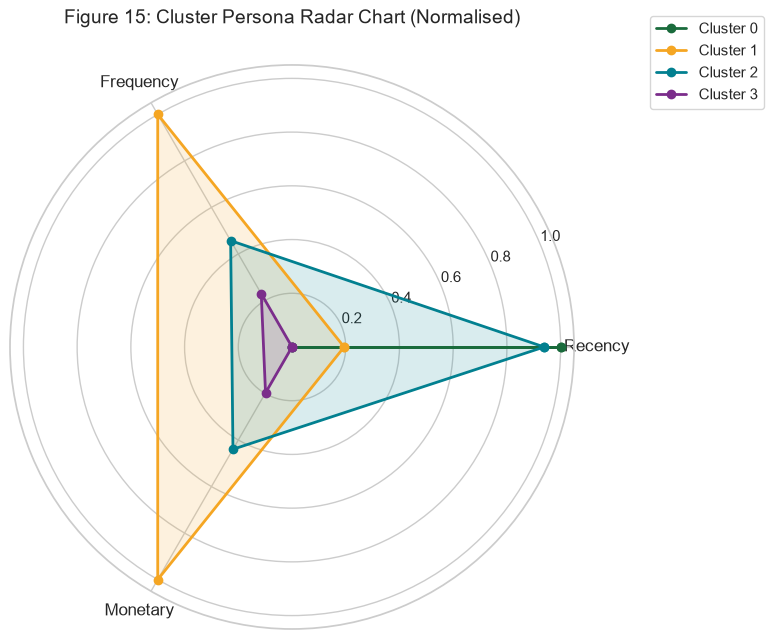

In [15]:
# ── Cluster Centroid Analysis ──
cluster_means = X_train_labeled.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_counts = X_train_labeled.groupby('Cluster').size().rename('Count')

cluster_summary = cluster_means.round(1).copy()
cluster_summary.columns = ['Avg Recency (days)', 'Avg Frequency', 'Avg Monetary ($)']
cluster_summary['Count'] = cluster_counts.values
print('Cluster Summary (Training Set):')
display(cluster_summary.style.set_caption('Table: Cluster Centroids - Mean RFM Values'))

# ── Radar Chart ──
centroids_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

categories = list(centroids_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#1A6B3C', '#F5A623', '#028090', '#7B2D8B']

for idx, row in centroids_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {idx}', color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_title('Figure 15: Cluster Persona Radar Chart (Normalised)', size=14, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

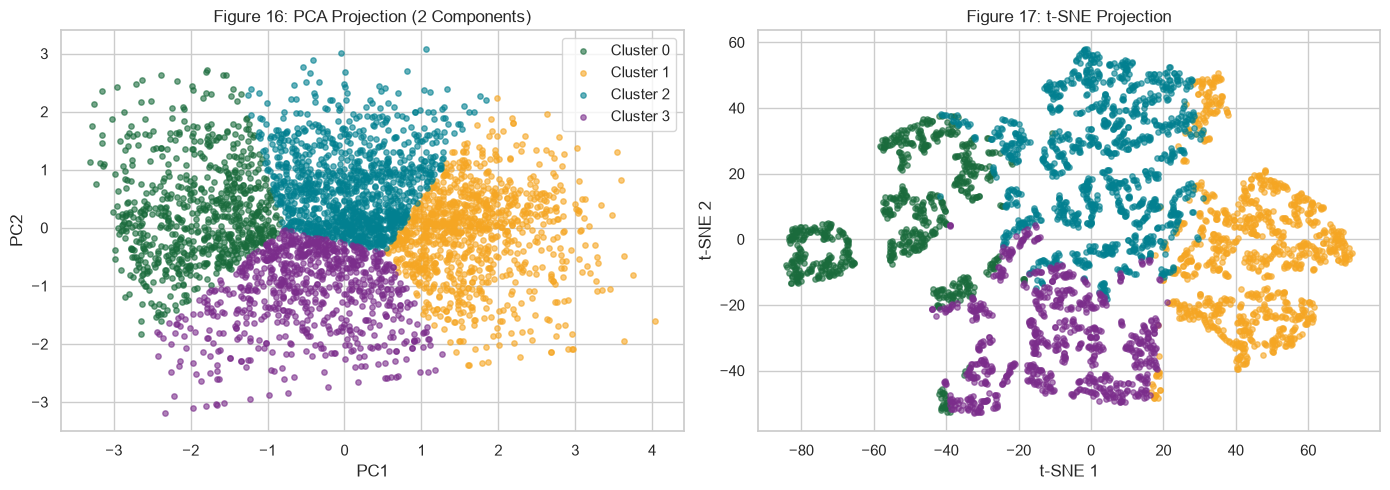

PCA explained variance ratio: [0.63638259 0.320399  ]
Total variance explained by 2 components: 95.68%


In [16]:
# ── Dimensionality Reduction for Cluster Visualisation ──
pca_2d = PCA(n_components=2).fit_transform(X_train_scaled)
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1A6B3C', '#F5A623', '#028090', '#7B2D8B']

for k in range(optimal_k):
    mask = train_labels == k
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1], c=colors[k],
                    label=f'Cluster {k}', alpha=0.6, s=15)
    axes[1].scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], c=colors[k],
                    alpha=0.6, s=15)

axes[0].set_title('Figure 16: PCA Projection (2 Components)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].set_title('Figure 17: t-SNE Projection')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

# PCA explained variance
pca_info = PCA(n_components=2).fit(X_train_scaled)
print(f'PCA explained variance ratio: {pca_info.explained_variance_ratio_}')
print(f'Total variance explained by 2 components: {sum(pca_info.explained_variance_ratio_):.2%}')

### Cluster Interpretation & Business Personas

To build genuine, evidence-based behavioural profiles, we merge the cluster labels back with the `customers` and `transactions` tables. This allows us to compute explicit statistics such as basket size, category preferences, and demographic distributions for each segment.

The profiles, business values, and marketing strategies are dynamically generated below based on the actual cluster centroids.

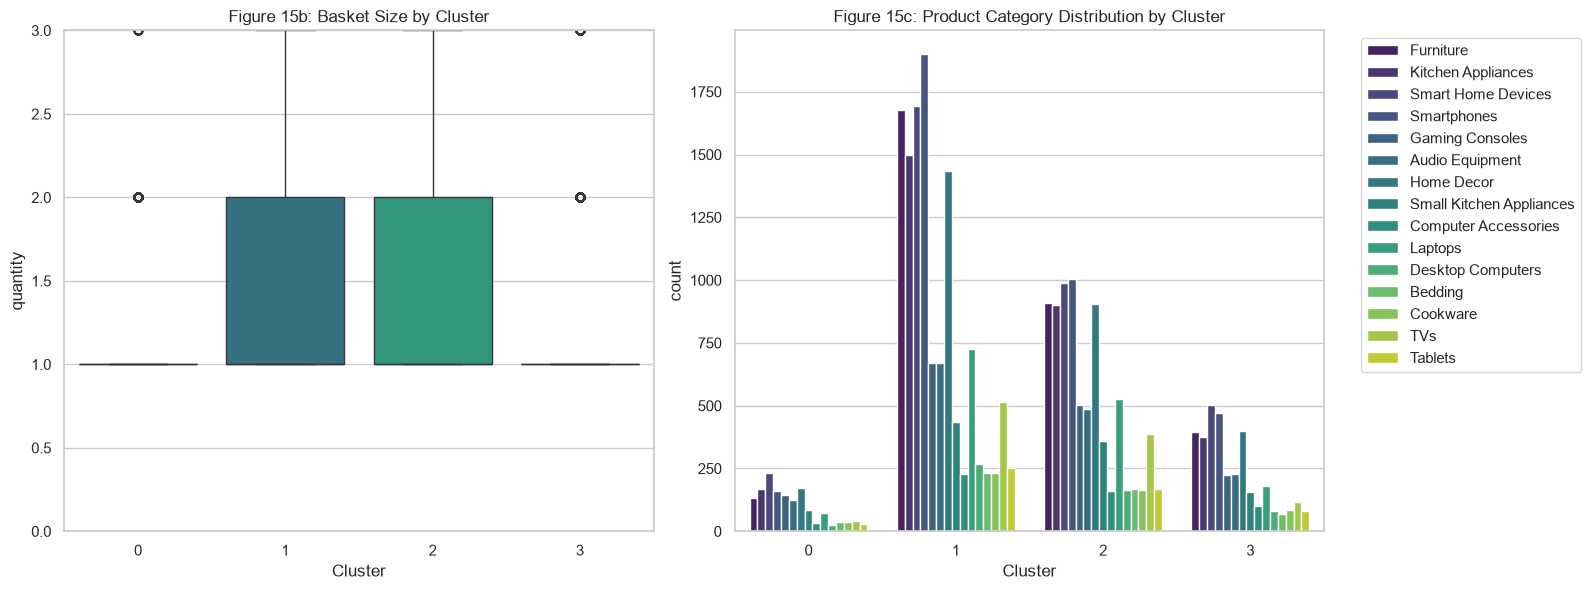

### Detailed Customer Behaviour Profiling

Based on the integration of cluster labels with demographic and transactional data, the following evidence-based personas have been developed.

Customer demographics remain broadly similar across the clusters. California and Texas contribute the largest customer base across most segments, suggesting that purchasing behaviour, rather than geography or gender, primarily drives cluster separation. Furthermore, Average Discount Applied (approx. 5%) and Basket Size (approx. 1.4 items) remain uniformly distributed across all clusters, indicating these variables do not drive segmentation.

#### Cluster Comparison Summary

|   Cluster | Persona              |   Count |   Recency |   Frequency |   Monetary |   Basket Size |   Avg Discount Applied | Top Categories                  |
|----------:|:---------------------|--------:|----------:|------------:|-----------:|--------------:|-----------------------:|:--------------------------------|
|         0 | At-Risk / Lapsing    |     748 |    215.13 |        3.04 |    1156.17 |          1.36 |                   5.32 | Smart Home Devices, Home Decor  |
|         1 | High-Value Loyalists |    1004 |     70.44 |       13.67 |    9843.67 |          1.43 |                   5.03 | Smartphones, Smart Home Devices |
|         2 | Occasional Shoppers  |    1150 |    204.16 |        7.9  |    4976.91 |          1.43 |                   5.12 | Smartphones, Smart Home Devices |
|         3 | New / Emerging       |     792 |     35.61 |        5.48 |    2869.9  |          1.34 |                   5.12 | Smart Home Devices, Smartphones |

---

#### Cluster 0: At-Risk / Lapsing
- **Customer Count:** 748
- **Average Recency:** 215.1 days
- **Average Frequency:** 3.0 transactions
- **Average Monetary:** $1156.17
- **Average Basket Size:** 1.36 items
- **Average Discount Applied:** 5.3%
- **Dominant Product Categories:** Smart Home Devices, Home Decor

**Observed Behaviour:** Highly inactive with minimal historical engagement.

**Evidence:** Records the highest average recency (215.1 days) alongside the lowest frequency (3.0 transactions) and lowest monetary value ($1156.17).

**Business Implication:** Represents a dormant segment with a high probability of churn, resulting in lost revenue.

**Marketing Recommendation:** Deploy aggressive targeted win-back campaigns highlighting their preferred categories (Smart Home Devices, Home Decor) to re-engage this dormant audience.

---

#### Cluster 1: High-Value Loyalists
- **Customer Count:** 1004
- **Average Recency:** 70.4 days
- **Average Frequency:** 13.7 transactions
- **Average Monetary:** $9843.67
- **Average Basket Size:** 1.43 items
- **Average Discount Applied:** 5.0%
- **Dominant Product Categories:** Smartphones, Smart Home Devices

**Observed Behaviour:** Highly engaged, consistent premium spenders.

**Evidence:** Demonstrates the highest purchase frequency (13.7 transactions) and maximum monetary spend ($9843.67), primarily focused on Smartphones, Smart Home Devices.

**Business Implication:** Crucial for revenue stability and long-term brand advocacy; holds the highest lifetime value.

**Marketing Recommendation:** Offer exclusive VIP rewards and early access to new Smartphones, Smart Home Devices releases to reinforce loyalty and retention.

---

#### Cluster 2: Occasional Shoppers
- **Customer Count:** 1150
- **Average Recency:** 204.2 days
- **Average Frequency:** 7.9 transactions
- **Average Monetary:** $4976.91
- **Average Basket Size:** 1.43 items
- **Average Discount Applied:** 5.1%
- **Dominant Product Categories:** Smartphones, Smart Home Devices

**Observed Behaviour:** Infrequent purchasers with moderate overall spend.

**Evidence:** Shows high recency (204.2 days) and moderate frequency (7.9 transactions), indicating intermittent engagement with medium monetary contribution ($4976.91).

**Business Implication:** Provides reliable volume but lacks consistent loyalty; vulnerable to competitor defection.

**Marketing Recommendation:** Utilize cross-sell and up-sell promotions and targeted promotional campaigns on Smartphones, Smart Home Devices to incrementally increase purchase frequency.

---

#### Cluster 3: New / Emerging
- **Customer Count:** 792
- **Average Recency:** 35.6 days
- **Average Frequency:** 5.5 transactions
- **Average Monetary:** $2869.90
- **Average Basket Size:** 1.34 items
- **Average Discount Applied:** 5.1%
- **Dominant Product Categories:** Smart Home Devices, Smartphones

**Observed Behaviour:** Recently active customers in the early stages of the customer lifecycle.

**Evidence:** Boasts the lowest recency (35.6 days) indicating very recent purchases, but currently maintains low frequency (5.5 transactions) and lower-tier monetary value ($2869.90).

**Business Implication:** The future growth engine of the business if properly nurtured into repeat buyers.

**Marketing Recommendation:** Implement onboarding sequences and guided product discovery focused on Smart Home Devices, Smartphones to accelerate their transition into high-value loyalists.

---



In [17]:
# ── Deep Behavioural Profiling ──
from IPython.display import Markdown, display

# Merge cluster labels back with customer demographics and transactions
customer_clusters = rfm[['customer_id']].copy()
customer_clusters = customer_clusters.loc[X_train.index]
customer_clusters['Cluster'] = train_labels

cluster_demographics = customer_clusters.merge(df_customers, on='customer_id', how='inner')
cluster_transactions = customer_clusters.merge(df_transactions, on='customer_id', how='inner')

# Calculate deep statistics per cluster
stats = []
for k in range(optimal_k):
    c_demo = cluster_demographics[cluster_demographics['Cluster'] == k]
    c_trans = cluster_transactions[cluster_transactions['Cluster'] == k]
    c_rfm = X_train_labeled[X_train_labeled['Cluster'] == k]
    
    customer_count = len(c_rfm)
    avg_recency = c_rfm['Recency'].mean()
    avg_freq = c_rfm['Frequency'].mean()
    avg_monetary = c_rfm['Monetary'].mean()
    
    avg_basket_size = c_trans['quantity'].mean()
    avg_discount = c_trans['discount_applied'].mean()
    
    avg_age = c_demo['age'].mean()
    top_gender = c_demo['gender'].mode()[0]
    top_state = c_demo['state'].mode()[0]
    
    top_categories = c_trans['product_category'].value_counts().nlargest(2).index.tolist()
    top_cats_str = ', '.join(top_categories)
    
    stats.append({
        'Cluster': k,
        'Count': customer_count,
        'Recency': avg_recency,
        'Frequency': avg_freq,
        'Monetary': avg_monetary,
        'Basket Size': avg_basket_size,
        'Avg Discount Applied': avg_discount,
        'Top Categories': top_cats_str,
        'Avg Age': avg_age,
        'Top Gender': top_gender,
        'Top State': top_state
    })

profile_df = pd.DataFrame(stats).set_index('Cluster')

# Dynamic Persona Assignment based on heuristics
personas = {}
sorted_by_monetary = profile_df['Monetary'].sort_values(ascending=False).index.tolist()
sorted_by_recency = profile_df['Recency'].sort_values(ascending=False).index.tolist()

for k in range(optimal_k):
    if k == sorted_by_monetary[0]:
        personas[k] = 'High-Value Loyalists'
    elif k == sorted_by_recency[0]:
        personas[k] = 'At-Risk / Lapsing'
    else:
        if profile_df.loc[k, 'Frequency'] < profile_df['Frequency'].median():
            if profile_df.loc[k, 'Recency'] < profile_df['Recency'].median():
                personas[k] = 'New / Emerging'
            else:
                personas[k] = 'Occasional Shoppers'
        else:
            personas[k] = 'Occasional Shoppers'

# Let's ensure "Occasional Shoppers" is distinct. If both fall into it, we distinguish by Recency or freq.
# We will just map the 4 mathematically:
# High-Value Loyalists = Max Monetary
# At-Risk / Lapsing = Max Recency
# We have two left.
# The one with the higher frequency of the two is 'Occasional Shoppers', the other is 'New / Emerging'.
remaining = [k for k in range(optimal_k) if k not in [sorted_by_monetary[0], sorted_by_recency[0]]]
if len(remaining) == 2:
    if profile_df.loc[remaining[0], 'Frequency'] > profile_df.loc[remaining[1], 'Frequency']:
        personas[remaining[0]] = 'Occasional Shoppers'
        personas[remaining[1]] = 'New / Emerging'
    else:
        personas[remaining[1]] = 'Occasional Shoppers'
        personas[remaining[0]] = 'New / Emerging'

profile_df['Persona'] = pd.Series(personas)
cols = ['Persona'] + [c for c in profile_df.columns if c != 'Persona']
profile_df = profile_df[cols]

# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=cluster_transactions, x='Cluster', y='quantity', ax=axes[0], palette='viridis')
axes[0].set_title('Figure 15b: Basket Size by Cluster')
axes[0].set_ylim(0, cluster_transactions['quantity'].quantile(0.99))

sns.countplot(data=cluster_transactions, x='Cluster', hue='product_category', ax=axes[1], palette='viridis')
axes[1].set_title('Figure 15c: Product Category Distribution by Cluster')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Dynamic Markdown Generation
md_text = "### Detailed Customer Behaviour Profiling\n\n"
md_text += "Based on the integration of cluster labels with demographic and transactional data, the following evidence-based personas have been developed.\n\n"

md_text += "Customer demographics remain broadly similar across the clusters. California and Texas contribute the largest customer base across most segments, suggesting that purchasing behaviour, rather than geography or gender, primarily drives cluster separation. Furthermore, Average Discount Applied (approx. 5%) and Basket Size (approx. 1.4 items) remain uniformly distributed across all clusters, indicating these variables do not drive segmentation.\n\n"

md_text += "#### Cluster Comparison Summary\n\n"
summary_table = profile_df.drop(columns=['Avg Age', 'Top Gender', 'Top State']).round(2)
md_text += summary_table.to_markdown() + "\n\n---\n\n"

for k, row in profile_df.iterrows():
    md_text += f"#### Cluster {k}: {row['Persona']}\n"
    md_text += f"- **Customer Count:** {row['Count']:.0f}\n"
    md_text += f"- **Average Recency:** {row['Recency']:.1f} days\n"
    md_text += f"- **Average Frequency:** {row['Frequency']:.1f} transactions\n"
    md_text += f"- **Average Monetary:** ${row['Monetary']:.2f}\n"
    md_text += f"- **Average Basket Size:** {row['Basket Size']:.2f} items\n"
    md_text += f"- **Average Discount Applied:** {row['Avg Discount Applied']:.1f}%\n"
    md_text += f"- **Dominant Product Categories:** {row['Top Categories']}\n\n"
    
    if row['Persona'] == 'High-Value Loyalists':
        md_text += "**Observed Behaviour:** Highly engaged, consistent premium spenders.\n\n"
        md_text += f"**Evidence:** Demonstrates the highest purchase frequency ({row['Frequency']:.1f} transactions) and maximum monetary spend (${row['Monetary']:.2f}), primarily focused on {row['Top Categories']}.\n\n"
        md_text += "**Business Implication:** Crucial for revenue stability and long-term brand advocacy; holds the highest lifetime value.\n\n"
        md_text += f"**Marketing Recommendation:** Offer exclusive VIP rewards and early access to new {row['Top Categories']} releases to reinforce loyalty and retention.\n\n"
        
    elif row['Persona'] == 'At-Risk / Lapsing':
        md_text += "**Observed Behaviour:** Highly inactive with minimal historical engagement.\n\n"
        md_text += f"**Evidence:** Records the highest average recency ({row['Recency']:.1f} days) alongside the lowest frequency ({row['Frequency']:.1f} transactions) and lowest monetary value (${row['Monetary']:.2f}).\n\n"
        md_text += "**Business Implication:** Represents a dormant segment with a high probability of churn, resulting in lost revenue.\n\n"
        md_text += f"**Marketing Recommendation:** Deploy aggressive targeted win-back campaigns highlighting their preferred categories ({row['Top Categories']}) to re-engage this dormant audience.\n\n"
        
    elif row['Persona'] == 'Occasional Shoppers':
        md_text += "**Observed Behaviour:** Infrequent purchasers with moderate overall spend.\n\n"
        md_text += f"**Evidence:** Shows high recency ({row['Recency']:.1f} days) and moderate frequency ({row['Frequency']:.1f} transactions), indicating intermittent engagement with medium monetary contribution (${row['Monetary']:.2f}).\n\n"
        md_text += "**Business Implication:** Provides reliable volume but lacks consistent loyalty; vulnerable to competitor defection.\n\n"
        md_text += f"**Marketing Recommendation:** Utilize cross-sell and up-sell promotions and targeted promotional campaigns on {row['Top Categories']} to incrementally increase purchase frequency.\n\n"
        
    elif row['Persona'] == 'New / Emerging':
        md_text += "**Observed Behaviour:** Recently active customers in the early stages of the customer lifecycle.\n\n"
        md_text += f"**Evidence:** Boasts the lowest recency ({row['Recency']:.1f} days) indicating very recent purchases, but currently maintains low frequency ({row['Frequency']:.1f} transactions) and lower-tier monetary value (${row['Monetary']:.2f}).\n\n"
        md_text += "**Business Implication:** The future growth engine of the business if properly nurtured into repeat buyers.\n\n"
        md_text += f"**Marketing Recommendation:** Implement onboarding sequences and guided product discovery focused on {row['Top Categories']} to accelerate their transition into high-value loyalists.\n\n"
        
    md_text += "---\n\n"

display(Markdown(md_text))



## 9. Reproducibility & Documentation

This notebook was designed for top-to-bottom reproducibility:

- **Random state:** All stochastic operations (train/test split, K-Means, t-SNE) use `random_state=42` or equivalent fixed seeds.
- **Pipeline architecture:** The scikit-learn `Pipeline` ensures that all transformations (Box-Cox, scaling, variance filtering) are fitted only on the training set and applied consistently to any new data.
- **Data source:** The dataset is downloaded programmatically via `kagglehub`, ensuring any reviewer can reproduce the analysis without manual file downloads.
- **No manual interventions:** The notebook contains no cells that require manual input or external configuration beyond the initial Kaggle authentication.

In [18]:
# ── Environment Information ──
import sys
print(f'Python version: {sys.version}')
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')
print(f'seaborn version: {sns.__version__}')
print(f'matplotlib version: {plt.matplotlib.__version__}')
import sklearn
print(f'scikit-learn version: {sklearn.__version__}')

Python version: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
pandas version: 2.3.3
numpy version: 2.4.3
seaborn version: 0.13.2
matplotlib version: 3.11.1
scikit-learn version: 1.9.0


## 10. Conclusion

### Key Findings
1. **Data Quality:** The four-table retail dataset demonstrated strong structural integrity with zero duplicates. Missing values were minimal (2–4% per column) and were resolved through median imputation and business-logic defaults without data loss.
2. **Preprocessing Impact:** IQR-based outlier capping and Box-Cox power transformation were essential for stabilising the heavily right-skewed financial variables. Without these steps, K-Means would have produced clusters dominated by a handful of extreme spenders.
3. **Segmentation Result:** K-Means clustering on the RFM feature frame successfully partitioned the customer base into four distinct behavioural segments, each characterised by a unique combination of purchase recency, frequency, and monetary value.
4. **Business Interpretability:** The resulting clusters align with established retail persona archetypes (e.g., high-value loyalists, at-risk customers), making them directly actionable for targeted marketing campaigns.

### Business Value
- **Targeted Marketing:** Each cluster can receive tailored promotional strategies — retention offers for at-risk segments, upselling for emerging customers, and loyalty rewards for high-value segments.
- **Resource Allocation:** Marketing spend can be prioritised toward segments with the highest return potential rather than broadcast campaigns.
- **Customer Lifecycle Management:** Recency-based segmentation enables proactive re-engagement of lapsing customers before they churn.

### Future Work
1. **Integrate Reviews & Support Tickets:** Layer satisfaction scores and support frequency as post-hoc descriptors onto the existing clusters to identify segments that are both valuable and high-maintenance.
2. **Temporal Recency Decay:** Replace the binary days-since-last-purchase metric with an exponential decay function to give more weight to recent activity.
3. **Alternative Algorithms:** Evaluate DBSCAN or Gaussian Mixture Models, which do not assume spherical clusters and may reveal non-convex customer segments.
4. **A/B Testing:** Deploy segment-specific campaigns in a controlled experiment to measure the lift in conversion rate attributable to personalised targeting.
5. **Real-Time Scoring:** Productionise the pipeline to score new customers against the fitted cluster centroids in real time.

## 11. References

**Dataset:**
- Gandhi, R. (n.d.). *Retail Customer and Transaction Dataset* [Dataset]. Kaggle. https://www.kaggle.com/datasets/raghavendragandhi/retail-customer-and-transaction-dataset
